<a href="https://colab.research.google.com/github/shivani11-glitch/seizure-detection/blob/main/eegdata.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install mne scikit-learn tqdm -q

import os, re, gc
import numpy as np
import mne
from scipy.signal import resample
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import Dataset, DataLoader, random_split
import torch
from tqdm import tqdm

print("✅ Ready!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 56.4 MB/s eta 0:00:00
✅ Ready!


In [ ]:
os.makedirs('./chb-mit/chb01', exist_ok=True)

base_url = "https://archive.physionet.org/physiobank/database/chbmit/chb01/"

files_to_download = [
    "chb01-summary.txt",
    "chb01_03.edf", "chb01_04.edf", "chb01_15.edf",
    "chb01_16.edf", "chb01_18.edf", "chb01_21.edf", "chb01_26.edf"
]

for f in files_to_download:
    out = f"./chb-mit/chb01/{f}"
    if not os.path.exists(out):
        print(f"Downloading {f}...")
        os.system(f'wget -q "{base_url}{f}" -O "{out}"')
    else:
        print(f"✅ Already exists: {f}")

print("\n📁 Files ready:")
print(os.listdir('./chb-mit/chb01/'))


📁 Files ready:
['chb01_16.edf', 'chb01_18.edf', 'chb01_15.edf', 'chb01_21.edf', 'chb01_03.edf', 'chb01_26.edf', 'chb01-summary.txt', 'chb01_04.edf']


In [ ]:
def parse_summary(summary_path):
    seizure_info = {}
    with open(summary_path, 'r') as f:
        content = f.read()

    file_blocks = re.split(r'File Name:', content)[1:]
    for block in file_blocks:
        lines    = block.strip().split('\n')
        filename = lines[0].strip()
        seizure_info[filename] = []

        num_match = re.search(r'Number of Seizures in File: (\d+)', block)
        if not num_match or int(num_match.group(1)) == 0:
            continue

        starts = re.findall(r'Seizure(?:\s+\d+)?\s+Start Time\s*:\s*(\d+)', block)
        ends   = re.findall(r'Seizure(?:\s+\d+)?\s+End Time\s*:\s*(\d+)', block)
        for s, e in zip(starts, ends):
            seizure_info[filename].append((int(s), int(e)))

    return seizure_info

summary = parse_summary('./chb-mit/chb01/chb01-summary.txt')

print("✅ Seizure annotations parsed:")
for fname, seiz in summary.items():
    if seiz:
        print(f"   {fname}: {seiz}")

✅ Seizure annotations parsed:
   chb01_03.edf: [(2996, 3036)]
   chb01_04.edf: [(1467, 1494)]
   chb01_15.edf: [(1732, 1772)]
   chb01_16.edf: [(1015, 1066)]
   chb01_18.edf: [(1720, 1810)]
   chb01_21.edf: [(327, 420)]
   chb01_26.edf: [(1862, 1963)]


In [ ]:
# ── EEGNet specific parameters ──
TARGET_SFREQ = 256   # EEGNet works best at 256 Hz
WINDOW_SEC   = 2     # 2s window = 512 samples
OVERLAP_SEC  = 1     # 1s step
N_CHANS      = 23    # CHB-MIT channels

# EEGNet input shape: (N, 1, n_chans, n_times)
# The extra dim "1" is the EEG "image" channel (like RGB=1 for greyscale)

def load_eegnet_windows(edf_path, seizure_times):
    # ── Load raw EDF ──
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
    raw.pick_types(eeg=True)
    raw.pick(raw.ch_names[:N_CHANS])

    # ── Bandpass filter (0.5–40 Hz for seizure detection) ──
    raw.filter(0.5, 40., fir_design='firwin', verbose=False)

    # ── Notch filter to remove powerline noise ──
    raw.notch_filter(freqs=60., verbose=False)

    # ── Resample to 256 Hz ──
    sfreq       = raw.info['sfreq']
    data        = raw.get_data()           # (23, n_times)
    new_n_times = int(data.shape[1] * TARGET_SFREQ / sfreq)
    data        = resample(data, new_n_times, axis=1)

    # ── Normalize per channel ──
    data = (data - data.mean(axis=1, keepdims=True)) / \
           (data.std(axis=1,  keepdims=True) + 1e-8)

    # ── Clip outliers (important for EEGNet stability) ──
    data = np.clip(data, -5, 5)

    # ── Sliding window ──
    win_len = int(WINDOW_SEC * TARGET_SFREQ)                   # 512
    step    = int((WINDOW_SEC - OVERLAP_SEC) * TARGET_SFREQ)   # 256

    X, y = [], []
    for start in range(0, new_n_times - win_len, step):
        end     = start + win_len
        t_start = start / TARGET_SFREQ
        t_end   = end   / TARGET_SFREQ

        label = 0
        for (sz_start, sz_end) in seizure_times:
            if t_start < sz_end and t_end > sz_start:
                label = 1
                break

        # EEGNet shape: (1, n_chans, n_times) — add channel dim here
        X.append(data[:, start:end][np.newaxis, :, :])
        y.append(label)

    del raw, data
    gc.collect()

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)


# ── Process seizure files only ──
seizure_files_only = {k: v for k, v in summary.items() if len(v) > 0}
print(f"Processing {len(seizure_files_only)} seizure files...\n")

all_X, all_y = [], []
for edf_file, sz_times in seizure_files_only.items():
    edf_path = f'./chb-mit/chb01/{edf_file}'
    if not os.path.exists(edf_path):
        print(f"  ⚠️  Skipping: {edf_file}")
        continue

    print(f"  Loading {edf_file}...")
    X, y = load_eegnet_windows(edf_path, sz_times)
    all_X.append(X)
    all_y.append(y)
    print(f"    Shape    : {X.shape}")         # (N, 1, 23, 512)
    print(f"    Seizure  : {y.sum()} | Non-seizure : {(y==0).sum()}")

X_all = np.concatenate(all_X, axis=0)
y_all = np.concatenate(all_y, axis=0)

del all_X, all_y
gc.collect()

print(f"\n✅ Final dataset")
print(f"   Shape       : {X_all.shape}")      # (N, 1, 23, 512)
print(f"   Seizure     : {y_all.sum()}")
print(f"   Non-seizure : {(y_all == 0).sum()}")
print(f"   RAM used    : {X_all.nbytes / 1e6:.1f} MB")

Processing 7 seizure files...

  Loading chb01_03.edf...


/tmp/ipykernel_905/267567446.py:12: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
    Shape    : (3598, 1, 23, 512)
    Seizure  : 41 | Non-seizure : 3557
  Loading chb01_04.edf...


/tmp/ipykernel_905/267567446.py:12: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
    Shape    : (3598, 1, 23, 512)
    Seizure  : 28 | Non-seizure : 3570
  Loading chb01_15.edf...


...

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
    Shape    : (3598, 1, 23, 512)
    Seizure  : 91 | Non-seizure : 3507
  Loading chb01_21.edf...


/tmp/ipykernel_905/267567446.py:12: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
    Shape    : (3598, 1, 23, 512)
    Seizure  : 94 | Non-seizure : 3504
  Loading chb01_26.edf...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


/tmp/ipykernel_905/267567446.py:12: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


    Shape    : (2323, 1, 23, 512)
    Seizure  : 102 | Non-seizure : 2221

✅ Final dataset
   Shape       : (23911, 1, 23, 512)
   Seizure     : 449
   Non-seizure : 23462
   RAM used    : 1126.3 MB


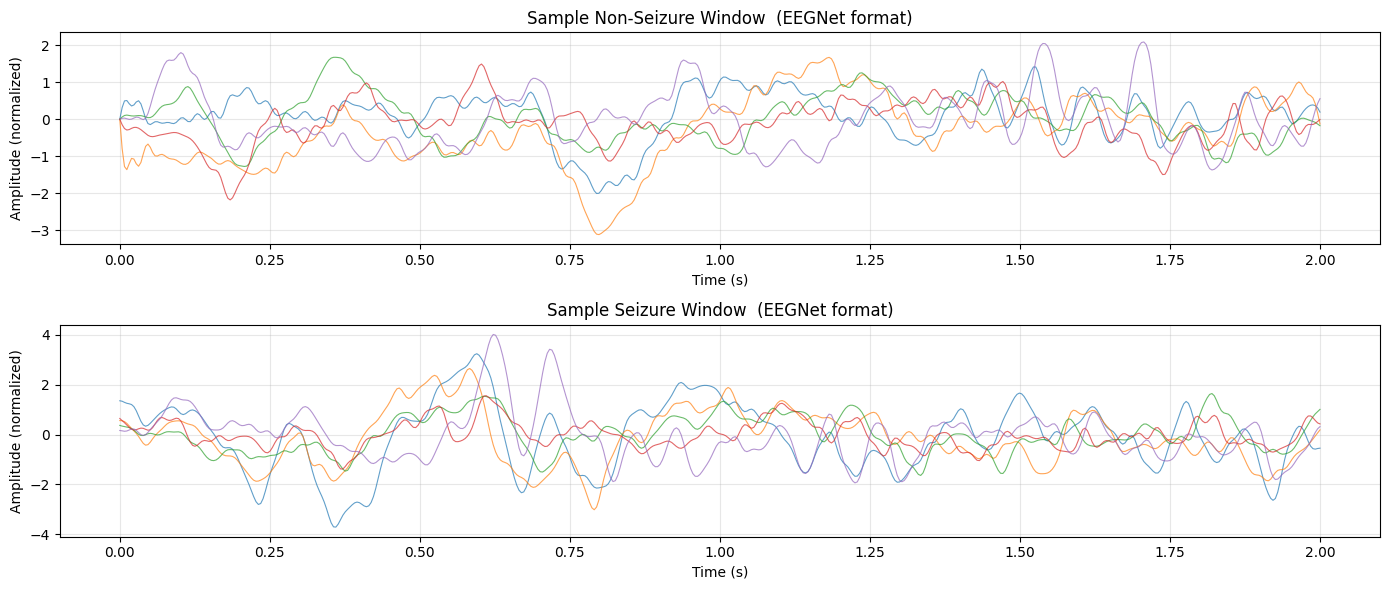

✅ Saved → eegnet_sample_windows.png


In [ ]:
import matplotlib.pyplot as plt

seiz_idx   = np.where(y_all == 1)[0][0]
normal_idx = np.where(y_all == 0)[0][0]

fig, axes = plt.subplots(2, 1, figsize=(14, 6))
time_axis = np.linspace(0, WINDOW_SEC, int(WINDOW_SEC * TARGET_SFREQ))

for i in range(5):    # plot first 5 channels
    # X_all shape is (N, 1, 23, 512) → squeeze the "1" dim
    axes[0].plot(time_axis, X_all[normal_idx][0][i], alpha=0.7, linewidth=0.8)
    axes[1].plot(time_axis, X_all[seiz_idx][0][i],   alpha=0.7, linewidth=0.8)

axes[0].set_title("Sample Non-Seizure Window  (EEGNet format)")
axes[1].set_title("Sample Seizure Window  (EEGNet format)")
for ax in axes:
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude (normalized)")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("eegnet_sample_windows.png", dpi=150)
plt.show()
print("✅ Saved → eegnet_sample_windows.png")

In [ ]:
from sklearn.model_selection import train_test_split

# ── 70 / 15 / 15 split ──
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=0.30,
    random_state=42, stratify=y_all
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50,
    random_state=42, stratify=y_temp
)

print(f"✅ Split complete:")
print(f"   Train : {X_train.shape} | Seizure: {y_train.sum()}")
print(f"   Val   : {X_val.shape}   | Seizure: {y_val.sum()}")
print(f"   Test  : {X_test.shape}  | Seizure: {y_test.sum()}")

# ── Class weights ──
class_weights = compute_class_weight('balanced',
                                      classes=np.array([0, 1]),
                                      y=y_train)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)
print(f"\nClass weights:")
print(f"   Non-Seizure : {class_weights[0]:.3f}")
print(f"   Seizure     : {class_weights[1]:.3f}")

# ── Free full array ──
del X_all, y_all
gc.collect()
print("✅ Freed X_all from RAM")

✅ Split complete:
   Train : (16737, 1, 23, 512) | Seizure: 314
   Val   : (3587, 1, 23, 512)   | Seizure: 68
   Test  : (3587, 1, 23, 512)  | Seizure: 67

Class weights:
   Non-Seizure : 0.510
   Seizure     : 26.651
✅ Freed X_all from RAM


In [ ]:
class EEGNetDataset(Dataset):
    def __init__(self, X, y):
        # float16 to save RAM, cast back to float32 on access
        self.X = torch.tensor(X, dtype=torch.float16)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx].float(), self.y[idx]

train_ds = EEGNetDataset(X_train, y_train)
val_ds   = EEGNetDataset(X_val,   y_val)
test_ds  = EEGNetDataset(X_test,  y_test)

# Free splits after dataset creation
del X_train, y_train, X_val, y_val, X_test, y_test
gc.collect()
print("✅ Freed split arrays from RAM")

train_loader = DataLoader(train_ds, batch_size=32,
                          shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=32,
                          shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_ds,  batch_size=32,
                          shuffle=False, num_workers=0, pin_memory=False)

print(f"\n✅ DataLoaders ready")
print(f"   Train : {len(train_ds)}")
print(f"   Val   : {len(val_ds)}")
print(f"   Test  : {len(test_ds)}")
print(f"   Batch : 32")

✅ Freed split arrays from RAM

✅ DataLoaders ready
   Train : 16737
   Val   : 3587
   Test  : 3587
   Batch : 32
